In [1]:
import torch
import pandas as pd
from torch_geometric.data import Data
from pathlib import Path
import os
os.chdir(Path().cwd().parent)
from modelling import get_dataframes
from modelling.metrics.metricstracker import MetricsTracker
import datetime
from graph_modelling.utils.load_data import load_train_val_data, load_test_data, read_csv_files
from graph_modelling.utils.tune_gnn import objective



Running __init__.py for data pipeline...
Modelling package initialized

/opt/rocm/lib/libamd_smi.so: cannot open shared object file: No such file or directory
Unable to find amdsmi library try installing amd-smi-lib from your package manager


2025-04-12 15:59:11.892481: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-12 15:59:11.892531: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-12 15:59:11.892553: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-12 15:59:11.899668: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-12 15:59:12.811724: W tensorflow/compiler/

In [2]:
HABROK = bool(0)                  # set to True if using HABROK; it will print
                                  # all stdout to a .txt file to log progress
BASE_DIR = Path.cwd()
MODEL_PATH = BASE_DIR / "results" / "models"
DATA_DIR = BASE_DIR / "data" / "data_combined"
ALL_DIR = DATA_DIR / "all"

print("BASE_DIR: ", BASE_DIR)
print("MODEL_PATH: ", MODEL_PATH)
print("ALL_DIR: ", ALL_DIR)

torch.manual_seed(34)             # set seed for reproducibility

N_HOURS_U = 72                    # number of hours to use for input
N_HOURS_Y = 24                    # number of hours to predict
N_HOURS_STEP = 24                 # "sampling rate" in hours of the data; e.g. 24 
                                  # means sample an I/O-pair every 24 hours
                                  # the contaminants and meteorological vars
CONTAMINANTS = ['NO2', 'O3'] # 'PM10', 'PM25']

BASE_DIR:  /home/nick/bachelor-project/forecasting_smog_DL_GNN
MODEL_PATH:  /home/nick/bachelor-project/forecasting_smog_DL_GNN/results/models
ALL_DIR:  /home/nick/bachelor-project/forecasting_smog_DL_GNN/data/data_combined/all


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

N_TRIALS = 50
N_EPOCHS = 500

cuda


In [4]:
import pickle

# Load the datasets
with open(ALL_DIR / "geometric_pkl" / "train_dataset.pkl", "rb") as f:
    train_dataset = pickle.load(f)
with open(ALL_DIR / "geometric_pkl" / "val_dataset.pkl", "rb") as f:
    val_dataset = pickle.load(f)
with open(ALL_DIR / "geometric_pkl" / "test_dataset.pkl", "rb") as f:
    test_dataset = pickle.load(f)


In [5]:
print("train_dataset: ", train_dataset)
print("val_dataset: ", val_dataset)
print("test_dataset: ", test_dataset)

train_dataset:  [Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_index=[2, 6], y=[3, 48]), Data(x=[3, 576], edge_i

In [ ]:
from graph_modelling.models.temporalgnn import TemporalGNN
from graph_modelling.models.basicgnn import BasicGNN

input_dim = N_HOURS_U * 8
output_dim = N_HOURS_Y * 2
model = TemporalGNN(input_dim=input_dim, output_dim=output_dim, hidden_dim=16)

model = model.to(device)
patience = 10

criterion = torch.nn.MSELoss()
model

TemporalGNN(
  (conv1): GCNConv(576, 16)
  (conv2): GCNConv(16, 16)
  (rnn): GRU(16, 16, batch_first=True)
  (fc_out): Linear(in_features=16, out_features=48, bias=True)
)

In [ ]:
import optuna
## 4. Optuna Study
study_name = f"basic-gnn-tuning-{current_time}"

storage_name = "sqlite:///gnn_tuning.db"

study = optuna.create_study(
    direction="minimize",
    study_name=study_name,
    storage=storage_name,
    load_if_exists=True,
    pruner=optuna.pruners.HyperbandPruner(),
)



[I 2025-04-12 15:59:19,369] Using an existing study with name 'abstract-gnn-tuning-' instead of creating a new one.


In [ ]:
study.optimize(
    lambda trial: objective(
        trial,
        model,  # Pass model here
        train_dataset, # Pass training data
        val_dataset,  # Pass validation data
        input_dim,
        output_dim,
        device=device, # Pass device as keyword argument
        num_epochs=N_EPOCHS, #reduced epochs for the demo
    ),
    n_trials=N_TRIALS,
)

/home/nick/bachelor-project/forecasting_smog_DL_GNN/.venv/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


  Using ReduceLROnPlateau: factor=0.1, patience=4, min_lr=7.829226803608719e-07
Trial 10 - Epoch 1/10 | Train Loss: 0.092310 | Val Loss: 0.073875 LR: 0.00001813


[I 2025-04-12 15:59:25,805] Trial 10 pruned. 


Trial 10 - Epoch 2/10 | Train Loss: 0.070283 | Val Loss: 0.052572 LR: 0.00001813
Trial 10 pruned at epoch 2.
  Using ReduceLROnPlateau: factor=0.5, patience=9, min_lr=1.0453460373313761e-07
Trial 11 - Epoch 1/10 | Train Loss: 0.036160 | Val Loss: 0.021658 LR: 0.00003489


[I 2025-04-12 15:59:38,295] Trial 11 pruned. 


Trial 11 - Epoch 2/10 | Train Loss: 0.020996 | Val Loss: 0.018184 LR: 0.00003489
Trial 11 pruned at epoch 2.


In [9]:
# --- Print Best Results ---
print("\n--- Optuna Study Complete ---")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial:")
best_trial = study.best_trial

print(f"  Value (Min Validation Loss): {best_trial.value:.6f}")
print(f"  Params: ")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")


--- Optuna Study Complete ---
Number of finished trials: 12
Best trial:
  Value (Min Validation Loss): 0.013329
  Params: 
    lr: 0.0001677412982562437
    weight_decay: 8.841298950303906e-05
    batch_size: 64
    hidden_dim: 80
    plateau_factor: 0.4
    plateau_patience: 9
    plateau_min_lr: 4.7648571886642455e-08


## Train Final Model

In [10]:
from torch_geometric.loader import DataLoader
final_model = TemporalGNN(
    input_dim=input_dim,
    output_dim=output_dim,
    hidden_dim=best_trial.params["hidden_dim"],
).to(device)

optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=best_trial.params["lr"],
    weight_decay=best_trial.params["weight_decay"],
)
criterion = torch.nn.MSELoss()
num_epochs = 10

train_loader = DataLoader(train_dataset, batch_size=best_trial.params["batch_size"], shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=best_trial.params["batch_size"], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=best_trial.params["batch_size"], shuffle=False)

In [ ]:
from graph_modelling.utils.train_gnn import train

train_losses, val_losses = train(final_model, train_loader, val_loader, optimizer, criterion, device, N_EPOCHS, patience)

Epoch 1/10 [Val]: 100%|██████████| 50/50 [00:00<00:00, 132.62batch/s, loss=0.0204]


[Epoch 1/10] Training Loss: 0.026865 | Validation Loss: 0.017528


Epoch 2/10 [Val]: 100%|██████████| 50/50 [00:00<00:00, 132.71batch/s, loss=0.018] 


[Epoch 2/10] Training Loss: 0.019110 | Validation Loss: 0.016195


Epoch 3/10 [Val]: 100%|██████████| 50/50 [00:00<00:00, 135.33batch/s, loss=0.0176]


...

[Epoch 8/10] Training Loss: 0.016098 | Validation Loss: 0.013183


Epoch 9/10 [Val]: 100%|██████████| 50/50 [00:00<00:00, 133.88batch/s, loss=0.0151]


[Epoch 9/10] Training Loss: 0.015889 | Validation Loss: 0.012986


Epoch 10/10 [Val]: 100%|██████████| 50/50 [00:00<00:00, 133.73batch/s, loss=0.0143]

[Epoch 10/10] Training Loss: 0.015742 | Validation Loss: 0.012847


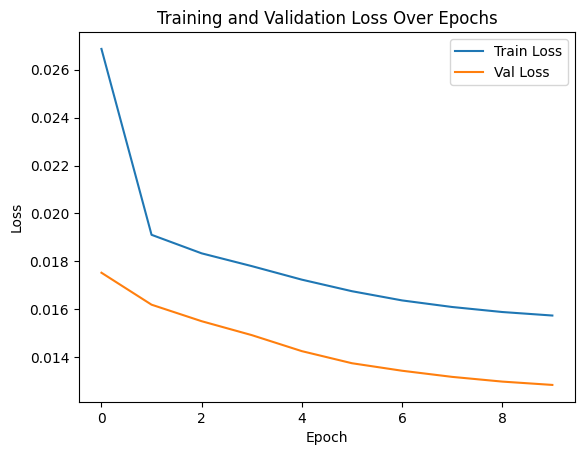

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss Over Epochs")
plt.savefig(MODEL_PATH / f"final_training_loss_tempgnn_{current_time}.png")


In [13]:
# Load y_min and y_max
with open(ALL_DIR / "geometric_pkl" / "y_min_max.pkl", "rb") as f:

    y_min, y_max = pickle.load(f)

In [ ]:
from graph_modelling.utils.test_gnn import predict_and_evaluate
_, _, _, preds, targets = predict_and_evaluate(
    final_model,
    test_loader,
    device,
    output_dim,
    y_min,
    y_max,
    N_HOURS_Y
)

Global RMSE (unnormalized): 21.4755
RMSE for NO2 (unnormalized): 16.3706
RMSE for O3 (unnormalized): 25.5812
